<a href="https://colab.research.google.com/github/SamyakVerma/Credit-Card-Fraud-Detection-System/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 — Setup & Install

This step installs all the necessary Python libraries required for the project, including LightGBM for gradient boosting, imbalanced-learn for handling class imbalance with SMOTE, scikit-learn for classical ML models and evaluation, and visualization libraries like matplotlib and seaborn. Having all dependencies installed upfront ensures a smooth workflow without interruptions later. This is a best practice for any reproducible ML project.

In [1]:
!pip install lightgbm imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
from google.colab import files
uploaded = files.upload()
# Select archive.zip from your Downloads folder when the dialog appears

Saving archive.zip to archive.zip


In [3]:
import zipfile, os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(os.listdir('/content/'))

['.config', 'creditcard.csv', 'archive.zip', 'sample_data']


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/creditcard.csv')
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%


/tmp/ipykernel_1674/2883327942.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])


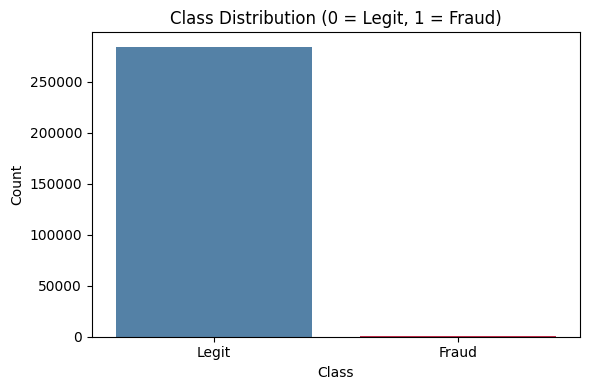

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df['Class'].value_counts())
print(f"\nFraud %: {df['Class'].mean() * 100:.4f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

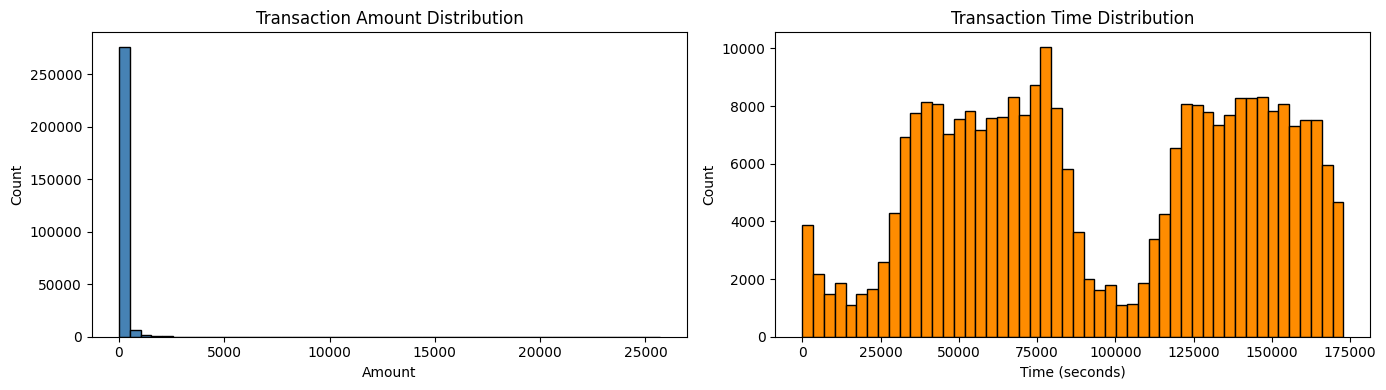

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

axes[1].hist(df['Time'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Sample 30k rows stratified
df_sampled = df.groupby('Class').apply(
    lambda x: x.sample(frac=30000/len(df), random_state=42)
).reset_index(drop=True)

print("Sampled shape:", df_sampled.shape)
print(df_sampled['Class'].value_counts())

# Scale Amount and Time
scaler = StandardScaler()
df_sampled['Amount'] = scaler.fit_transform(df_sampled[['Amount']])
df_sampled['Time']   = scaler.fit_transform(df_sampled[['Time']])

# Split features and target
X = df_sampled.drop('Class', axis=1)
y = df_sampled['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Sampled shape: (30000, 31)
Class
0    29948
1       52
Name: count, dtype: int64

Train: (24000, 30), Test: (6000, 30)


/tmp/ipykernel_1674/3713919144.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('Class').apply(


Before SMOTE: {0: 23958, 1: 42}
After SMOTE:  {0: 23958, 1: 23958}


/tmp/ipykernel_1674/3892878947.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette=['steelblue','crimson'], ax=axes[0])
/tmp/ipykernel_1674/3892878947.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette=['steelblue','crimson'], ax=axes[1])


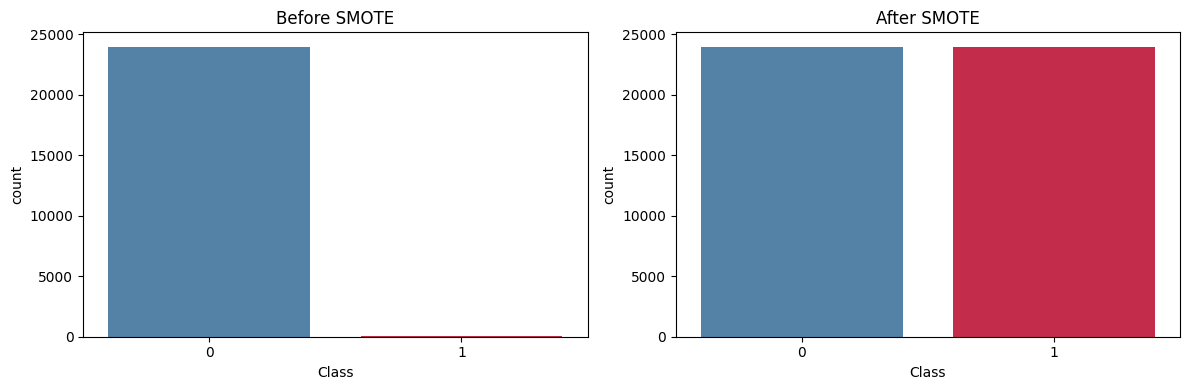

In [9]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

import pandas as pd
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('Before SMOTE')
sns.countplot(x=y_train_res, palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
print("Logistic Regression trained ✅")

Logistic Regression trained ✅


In [11]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
lgbm.fit(X_train_res, y_train_res)
print("LightGBM trained ✅")

[LightGBM] [Info] Number of positive: 23958, number of negative: 23958
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 47916, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM trained ✅


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.7932 - val_loss: 0.6989
Epoch 2/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5386 - val_loss: 0.5631
Epoch 3/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4551 - val_loss: 0.5024
Epoch 4/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4201 - val_loss: 0.4631
Epoch 5/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4024 - val_loss: 0.4463
Epoch 6/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3913 - val_loss: 0.4377
Epoch 7/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3831 - val_loss: 0.4281
Epoch 8/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3767 - val_loss: 0.4220
Epoch 9/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3720 - val_loss: 0.4146
Epoch 10/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3669 - val_loss: 0.4082
Epoch 11/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3621 - val_loss: 0.4098
Epoch 12/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

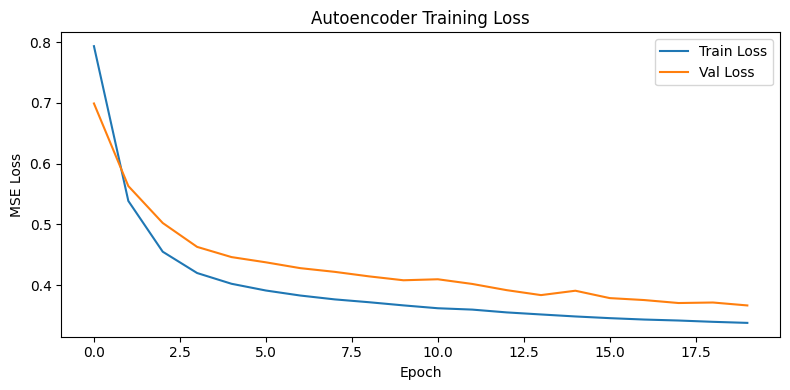

749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Anomaly threshold: 0.764842


In [12]:
import tensorflow as tf
from tensorflow import keras

# Train only on legit transactions
X_train_normal = X_train_res[y_train_res == 0]

n_features = X_train.shape[1]

# Build autoencoder
inputs = keras.Input(shape=(n_features,))
encoded = keras.layers.Dense(16, activation='relu')(inputs)
encoded = keras.layers.Dense(8,  activation='relu')(encoded)
decoded = keras.layers.Dense(16, activation='relu')(encoded)
outputs = keras.layers.Dense(n_features, activation='linear')(decoded)

autoencoder = keras.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Set fraud threshold at 95th percentile of normal reconstruction error
train_recon = autoencoder.predict(X_train_normal)
train_errors = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)
threshold = np.percentile(train_errors, 95)
print(f"\nAnomaly threshold: {threshold:.6f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      5990
       Fraud       0.20      0.60      0.30        10

    accuracy                           1.00      6000
   macro avg       0.60      0.80      0.65      6000
weighted avg       1.00      1.00      1.00      6000



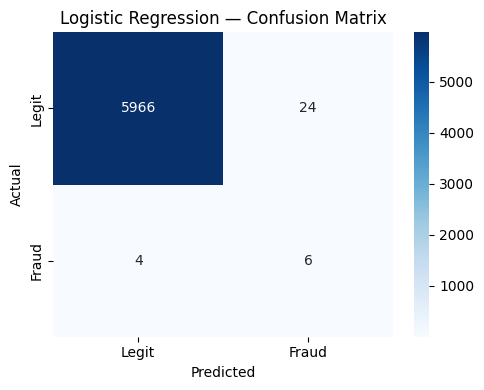

ROC-AUC: 0.9460  |  PR-AUC: 0.3886


In [13]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legit','Fraud']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

lr_roc = roc_auc_score(y_test, y_prob_lr)
lr_pr  = average_precision_score(y_test, y_prob_lr)
print(f"ROC-AUC: {lr_roc:.4f}  |  PR-AUC: {lr_pr:.4f}")

=== LightGBM ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      5990
       Fraud       0.60      0.60      0.60        10

    accuracy                           1.00      6000
   macro avg       0.80      0.80      0.80      6000
weighted avg       1.00      1.00      1.00      6000



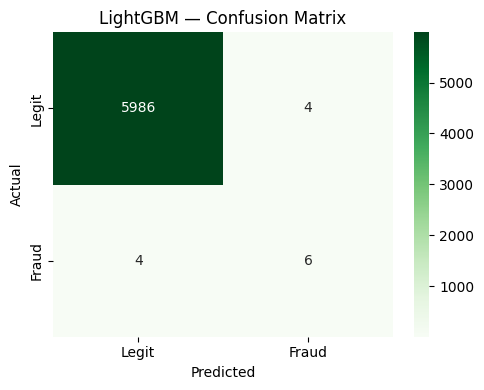

ROC-AUC: 0.7099  |  PR-AUC: 0.4791


In [14]:
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legit','Fraud']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('LightGBM — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

lgbm_roc = roc_auc_score(y_test, y_prob_lgbm)
lgbm_pr  = average_precision_score(y_test, y_prob_lgbm)
print(f"ROC-AUC: {lgbm_roc:.4f}  |  PR-AUC: {lgbm_pr:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
=== Autoencoder ===
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97      5990
       Fraud       0.03      1.00      0.06        10

    accuracy                           0.95      6000
   macro avg       0.52      0.97      0.52      6000
weighted avg       1.00      0.95      0.97      6000



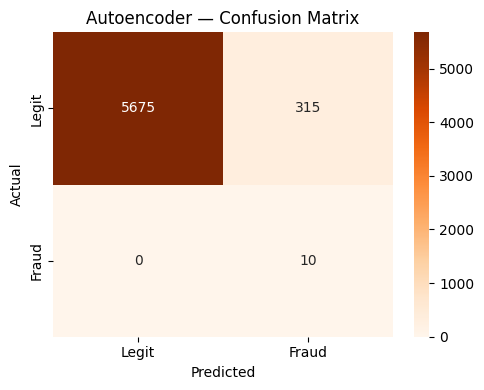

ROC-AUC: 0.9937  |  PR-AUC: 0.3367


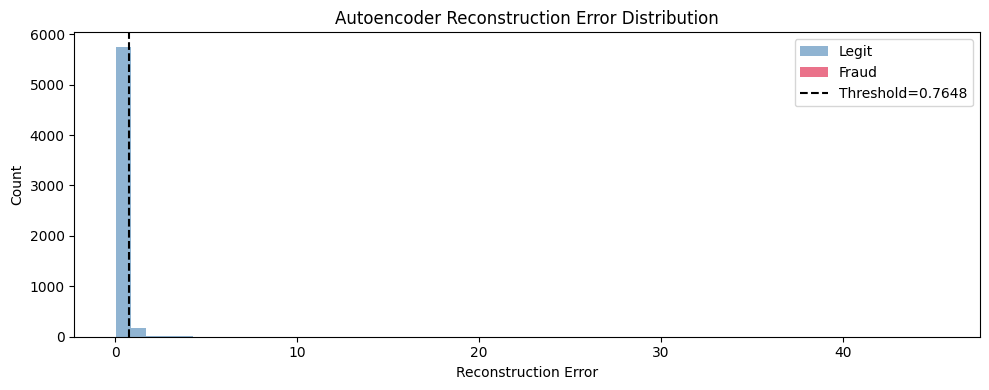

In [15]:
test_recon  = autoencoder.predict(X_test)
test_errors = np.mean(np.power(X_test.values - test_recon, 2), axis=1)

y_pred_ae = (test_errors > threshold).astype(int)
y_prob_ae = test_errors  # higher error = more likely fraud

print("=== Autoencoder ===")
print(classification_report(y_test, y_pred_ae, target_names=['Legit','Fraud']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ae), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title('Autoencoder — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

ae_roc = roc_auc_score(y_test, y_prob_ae)
ae_pr  = average_precision_score(y_test, y_prob_ae)
print(f"ROC-AUC: {ae_roc:.4f}  |  PR-AUC: {ae_pr:.4f}")

# Reconstruction error distribution
plt.figure(figsize=(10, 4))
plt.hist(test_errors[y_test == 0], bins=50, alpha=0.6, label='Legit', color='steelblue')
plt.hist(test_errors[y_test == 1], bins=50, alpha=0.6, label='Fraud', color='crimson')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.4f}')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

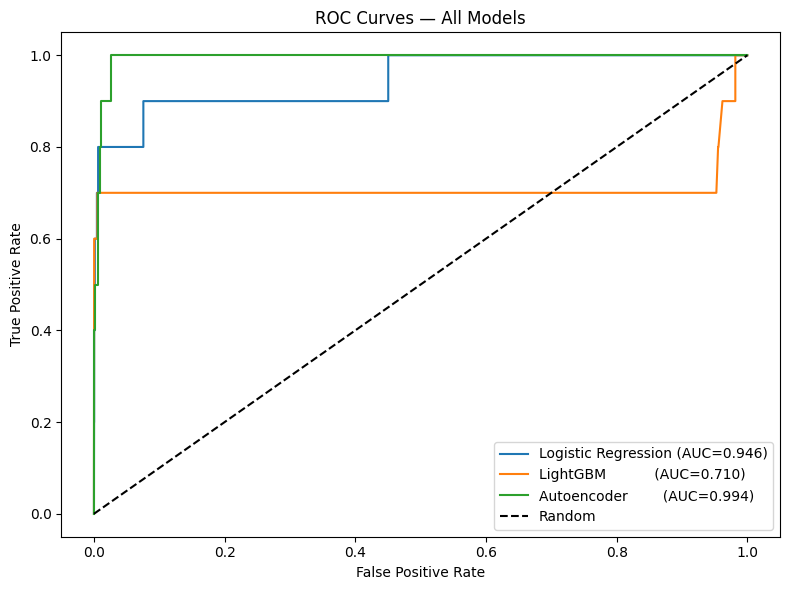

In [16]:
from sklearn.metrics import roc_curve

fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
fpr_ae,   tpr_ae,   _ = roc_curve(y_test, y_prob_ae)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,   tpr_lr,   label=f'Logistic Regression (AUC={lr_roc:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM           (AUC={lgbm_roc:.3f})')
plt.plot(fpr_ae,   tpr_ae,   label=f'Autoencoder        (AUC={ae_roc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.title('ROC Curves — All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

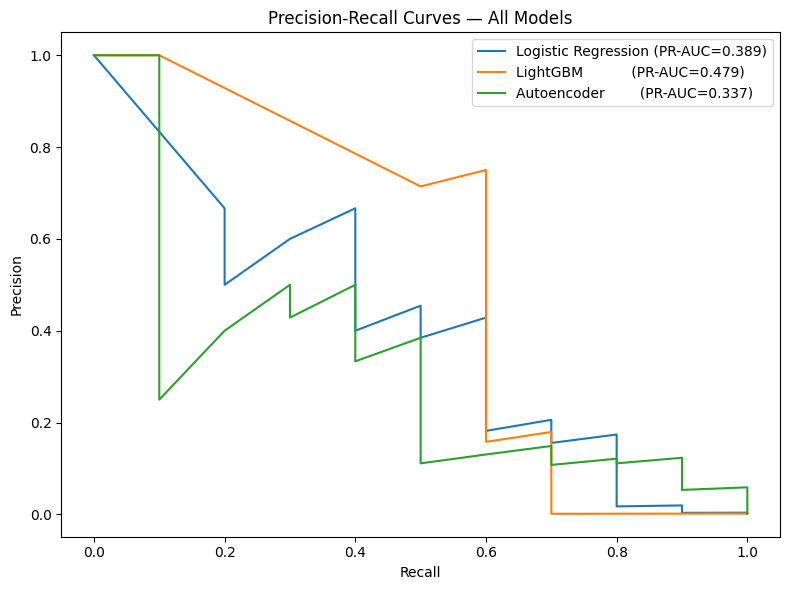

In [17]:
from sklearn.metrics import precision_recall_curve

pre_lr,   rec_lr,   _ = precision_recall_curve(y_test, y_prob_lr)
pre_lgbm, rec_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)
pre_ae,   rec_ae,   _ = precision_recall_curve(y_test, y_prob_ae)

plt.figure(figsize=(8, 6))
plt.plot(rec_lr,   pre_lr,   label=f'Logistic Regression (PR-AUC={lr_pr:.3f})')
plt.plot(rec_lgbm, pre_lgbm, label=f'LightGBM           (PR-AUC={lgbm_pr:.3f})')
plt.plot(rec_ae,   pre_ae,   label=f'Autoencoder        (PR-AUC={ae_pr:.3f})')
plt.title('Precision-Recall Curves — All Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

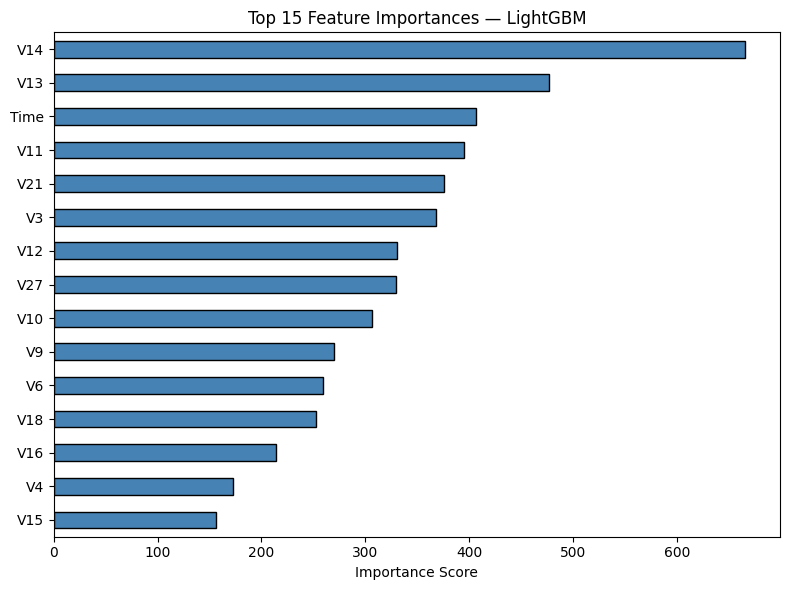

In [18]:
feat_imp = pd.Series(lgbm.feature_importances_, index=X.columns)
feat_imp = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Model':     ['Logistic Regression', 'LightGBM', 'Autoencoder'],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_ae)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_ae)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_ae)
    ],
    'ROC-AUC': [lr_roc,   lgbm_roc,   ae_roc],
    'PR-AUC':  [lr_pr,    lgbm_pr,    ae_pr]
})

summary = summary.set_index('Model').round(4)
print(summary.to_string())
summary.style.highlight_max(color='lightgreen').highlight_min(color='lightyellow')

                     Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                            
Logistic Regression     0.2000     0.6    0.3000   0.9460  0.3886
LightGBM                0.6000     0.6    0.6000   0.7099  0.4791
Autoencoder             0.0308     1.0    0.0597   0.9937  0.3367


,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.200000,0.600000,0.300000,0.946000,0.388600
LightGBM,0.600000,0.600000,0.600000,0.709900,0.479100
Autoencoder,0.030800,1.000000,0.059700,0.993700,0.336700
